In [2]:
from nrem_analysis.constant import PROCESSED_DIR, INTERIM_DIR, MOUSE_IDS_DUAL

import pynapple as nap
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import cmap

STATE_NAMES = ["continuous", "fragmented", "stationary"]

In [166]:
mouse_id = "99b"
sleep = nap.load_file(PROCESSED_DIR / "dual" / mouse_id / "sleep.npz")
turn_units = nap.load_file(PROCESSED_DIR / "dual" / mouse_id / "turn_units.npz")
head_direction = nap.load_file(PROCESSED_DIR / "dual" / mouse_id / "head_direction.npz")
nrem = sleep[sleep['state'] == 'nrem']

virtual_hds = []
states = []
for i, ep in enumerate(nrem):
    decoded = nap.load_file(INTERIM_DIR / mouse_id / f"{mouse_id}_{i}.npz")
    states_i = nap.TsdFrame(t=decoded.t, d=decoded.values[:, :3], columns=STATE_NAMES)
    virtual_hd = nap.Tsd(t=decoded.t, d=decoded.values[:, 3])
    
    states.append(states_i)
    virtual_hds.append(virtual_hd)

vh = np.concatenate(virtual_hds)
states = np.concatenate(states)

In [167]:
angles = np.deg2rad(vh.d)
d = np.column_stack([np.sin(angles), np.cos(angles)])
vh_prime = nap.TsdFrame(t=vh.t, d=d, columns=['sin_hd', 'cos_hd'], time_support=nrem)
vh_prime

Time (s)       sin_hd     cos_hd
----------  ---------  ---------
5361.0005    0.894946  -0.446175
5361.0015    0.894946  -0.446175
5361.0025    0.91707   -0.398726
5361.0035    0.894946  -0.446175
5361.0045    0.887023  -0.461726
5361.0055    0.894946  -0.446175
5361.0065    0.963637  -0.267216
...
40887.9935  -0.930441   0.366441
40887.9945  -0.930441   0.366441
40887.9955  -0.930441   0.366441
40887.9965  -0.930441   0.366441
40887.9975  -0.930441   0.366441
40887.9985  -0.923859  -0.382734
40887.9995  -0.930441   0.366441
dtype: float64, shape: (11796000, 2)

In [ ]:
sta_prime = nap.compute_event_triggered_average(vh_prime, turn_units, binsize=1, window=(-500, 500), time_unit='ms', epochs=nrem)

In [196]:
sta = nap.TsdFrame(t=sta_prime.t, d=np.rad2deg(np.arctan2(sta_prime[:, :, 0].d, sta_prime[:, :, 1].d)))

In [211]:
order = np.argsort(turn_units['turn_index'].values)
zero_idx = np.where(sta.index == 0)[0].item()
baseline = sta[zero_idx, :]
sta_norm = sta - baseline
# sta_norm = sta_norm.smooth(std=5, time_units='ms')

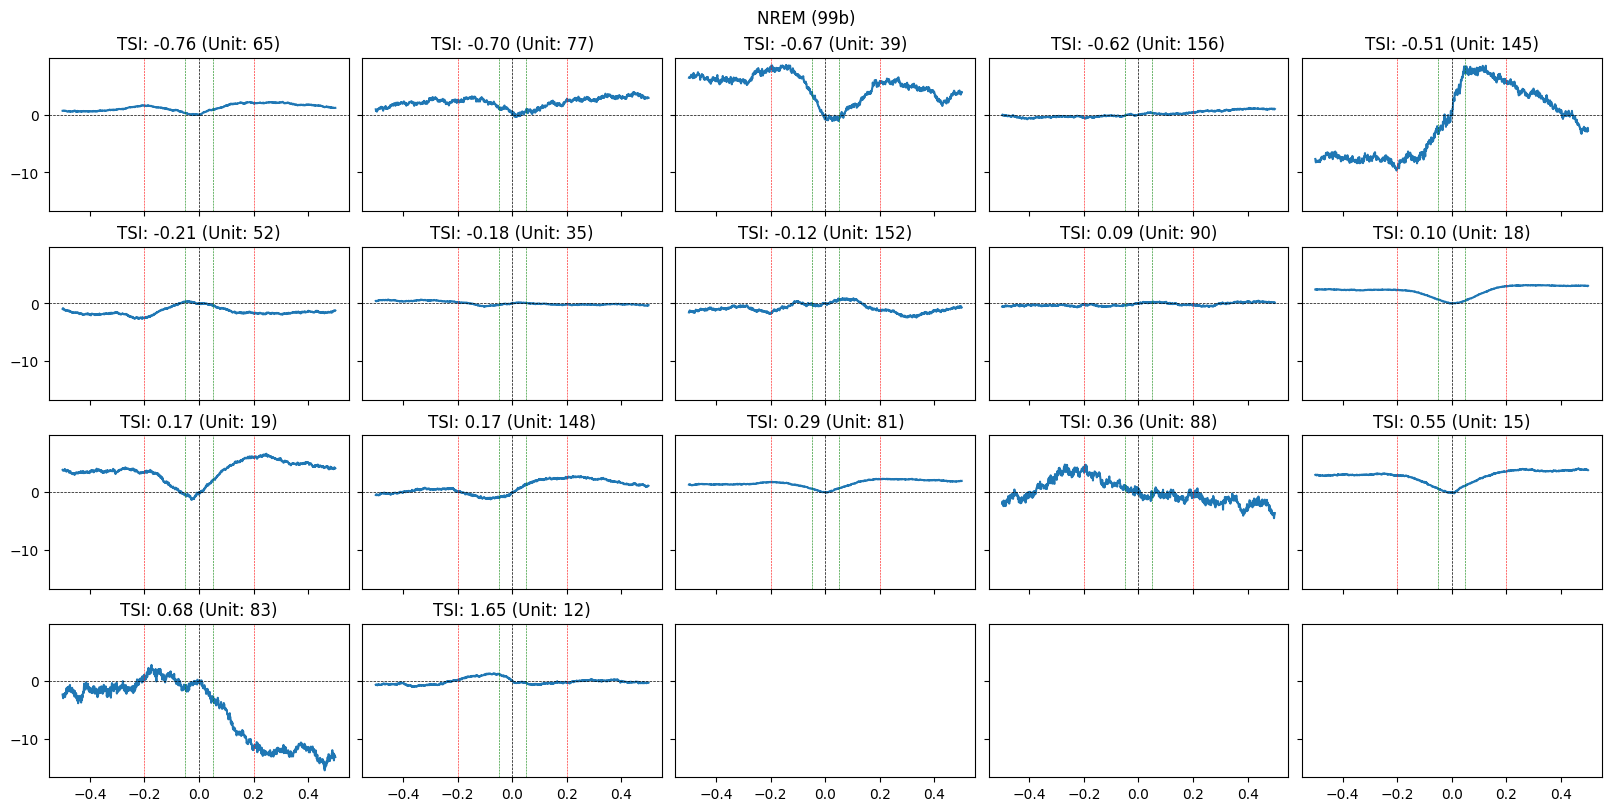

In [241]:
ncols = 5
nrows = int(np.ceil(sta_norm.shape[1] / ncols))

f, axs = plt.subplots(
    nrows, ncols,
    figsize=(16, 8),
    sharex=True,
    sharey=True,
    constrained_layout=True,
    )

axs = axs.flatten()
for i, idx in enumerate(order):
    uid = turn_units.index[idx].item()
    ax = axs[i]
    ax.plot(sta_norm[:, idx])
    ax.set_title(f"TSI: {turn_units['turn_index'].values[idx]:.2f} (Unit: {uid})")
    ax.axvline(0, color='k', linestyle='--', linewidth=0.5)
    ax.axhline(0, color='k', linestyle='--', linewidth=0.5)
    ax.axvline(0.2, color='r', linestyle='--', linewidth=0.4)
    ax.axvline(-0.2, color='r', linestyle='--', linewidth=0.4)
    ax.axvline(0.05, color='g', linestyle='--', linewidth=0.4)
    ax.axvline(-0.05, color='g', linestyle='--', linewidth=0.4)
f.suptitle(f"NREM ({mouse_id})")
plt.show()

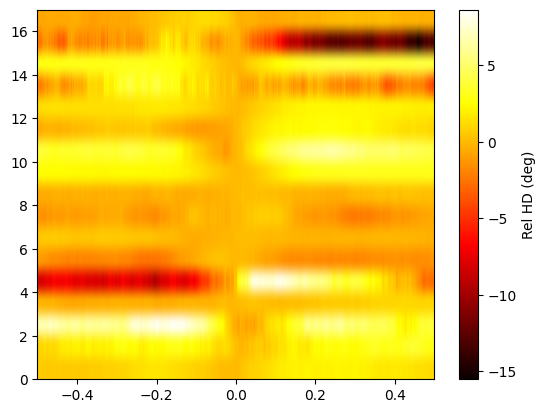

In [240]:
im = plt.imshow(sta_norm.d[:, order].T, aspect='auto', origin='lower', extent=[sta_norm.index[0], sta_norm.index[-1], 0, sta_norm.shape[1]], cmap='hot')
plt.colorbar(im, label='Rel HD (deg)')

(5361.0, 5381.0)

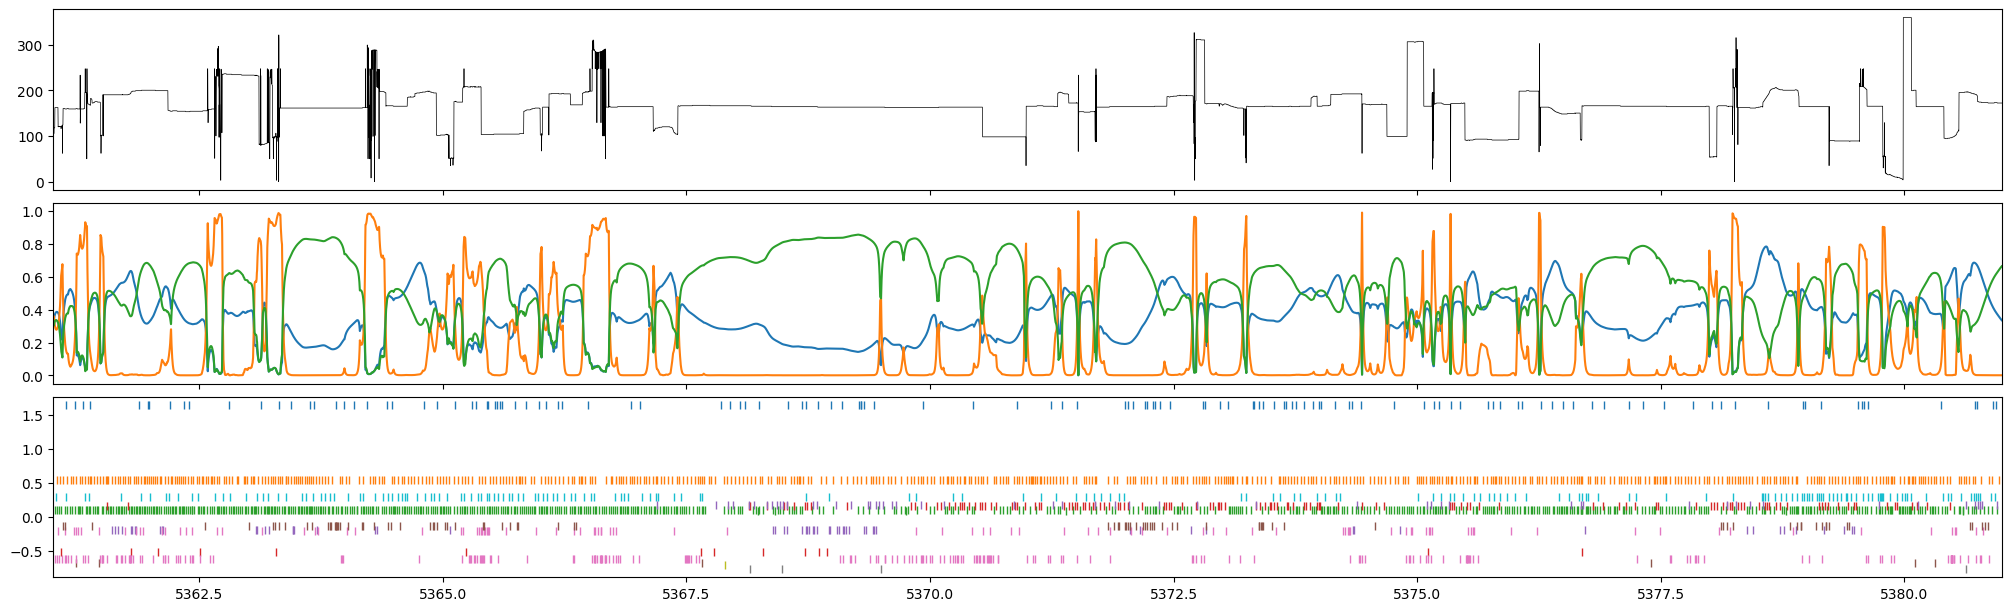

In [52]:
fig, axs = plt.subplots(3, 1, figsize=(20, 6), constrained_layout=True, sharex=True)
axs[0].plot(virtual_hd, color='k', linewidth=0.5)
axs[1].plot(states, label=STATE_NAMES)

for uid in turn_spikes:
    turn_index = turn_spikes['turn_index'][uid].item()
    axs[2].plot(turn_spikes[uid].fillna(turn_index), '|')

axs[0].set_xlim((ep.start, ep.start + 20))